# Porsche AG (P911) Hisse Senedi Fiyat Tahmini – Proje Raporu

## Bilimsel Sorular

Bu proje aşağıdaki araştırma sorularını cevaplamayı hedeflemektedir:

1. **Trend Analizi:** Porsche AG (P911) hisse senedi fiyatları 2022–2026 döneminde nasıl bir trend göstermektedir?
2. **Durağanlık:** Fiyat serisi durağan mıdır, yoksa belirgin trend ve volatilite içeriyor mu?
3. **Tahmin Edilebilirlik:** Geçmiş fiyat verileri kullanılarak gelecekteki kapanış fiyatları (veya hareket şiddeti) tahmin edilebilir mi?
4. **Model Karşılaştırması:** Random Forest, XGBoost ve ARIMA modelleri arasında hangisi daha başarılı sonuç vermektedir?
5. **Volatilite Etkisi:** Volatil dönemlerde model performansı nasıl değişmektedir?

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [2]:
import kagglehub
import os

print("Veri seti indiriliyor...")
path = kagglehub.dataset_download("sanaijlalshahrukh/porsche-ag-historical-stock-prices-2022-2026")

dosyalar = os.listdir(path)
csv_dosyasi = [f for f in dosyalar if f.endswith('.csv')][0]
csv_yolu = os.path.join(path, csv_dosyasi)

df_raw = pd.read_csv(csv_yolu)

print("Dataset çekildi!\n")
print(f"Ham veri boyutu: {df_raw.shape}")
df_raw.head()

Veri seti indiriliyor...
Dataset çekildi!

Ham veri boyutu: (866, 6)


,date,open,high,low,close,volume
0,2022-09-30,75.617410,76.164700,75.252548,75.252548,5079137
1,2022-10-03,75.252548,75.453222,73.884320,74.614044,2403446
2,2022-10-04,75.434974,79.795067,74.796470,79.795067,1599630
3,2022-10-05,79.448447,81.765314,78.919397,80.196411,1321304
4,2022-10-06,81.820036,85.468644,81.491661,82.750435,2217065


## 1. Veri Kaynağı ve Değişkenler

### 1.1 Veri Kaynağı

Kullanılan veri seti **Kaggle** platformundan temin edilmiştir:  
Kaynak: *Porsche AG Historical Stock Prices 2022–2026* (sanaijlalshahrukh, Kaggle)  

Veri, Porsche AG'nin (hisse kodu: **P911.DE**, Frankfurt/XETRA) **Eylül 2022 – Nisan 2026**  
tarihleri arasındaki günlük hisse senedi işlem verilerini içermektedir.  
Her satır bir işlem gününe karşılık gelir; hafta sonları ve resmi tatiller veri setinde yer almaz.

---

### 1.2 Değişkenler, Anlamları ve Ölçüm Seviyeleri

| Değişken | Açıklama | Ölçüm Seviyesi | Birim |
|----------|----------|----------------|-------|
| `date` | İşlem günü tarihi | Zaman indeksi | YYYY-MM-DD |
| `open` | Seans açılış fiyatı (günün ilk işlem fiyatı) | Oran (Ratio) | EUR |
| `high` | Seans içi en yüksek fiyat | Oran (Ratio) | EUR |
| `low` | Seans içi en düşük fiyat | Oran (Ratio) | EUR |
| `close` | Kapanış fiyatı – analizlerde **temel hedef değişken** | Oran (Ratio) | EUR |
| `volume` | Günlük toplam işlem adedi | Oran (Ratio) | Lot (Adet) |

> **Ölçüm Seviyesi Notu:** Tüm fiyat ve hacim değişkenleri **oran ölçeğindedir** (ratio scale):
> mutlak sıfır anlamlıdır (0 EUR = işlem yok), değerler arasındaki oranlar yorumlanabilir
> (örn. getiri = Δfiyat/fiyat), toplama ve bölme işlemleri matematiksel olarak geçerlidir.

---

### 1.3 Türetilen Değişkenler

| Değişken | Formül / Açıklama | Ölçüm Seviyesi |
|----------|-------------------|----------------|
| `daily_return` | `(close_t − close_{t-1}) / close_{t-1}` | Oran |
| `log_return` | `ln(close_t / close_{t-1})` | Aralık (Interval) |
| `direction` | +1 yükseliş / −1 düşüş / 0 yatay | Nominal (Kategorik) |
| `SMA_20/50/200` | 20, 50 ve 200 günlük hareketli ortalama | Oran |
| `volatility_yearly` | `std(log_return, 252) × √252` | Oran |
| `drawdown` | `(close − rolling_max) / rolling_max` | Oran (negatif) |
| `yearly_return` | 252 günlük bileşik getiri (zincirleme çarpım) | Oran |

---


In [3]:
# Tablo 1 – Ham Veriden 10 Satır Örnek
print("Tablo 1 – Ham Veri Örneği (ilk 10 satır):")
display(df_raw.head(10))

Tablo 1 – Ham Veri Örneği (ilk 10 satır):


,date,open,high,low,close,volume
0,2022-09-30,75.617410,76.164700,75.252548,75.252548,5079137
1,2022-10-03,75.252548,75.453222,73.884320,74.614044,2403446
2,2022-10-04,75.434974,79.795067,74.796470,79.795067,1599630
3,2022-10-05,79.448447,81.765314,78.919397,80.196411,1321304
4,2022-10-06,81.820036,85.468644,81.491661,82.750435,2217065
5,2022-10-07,82.750444,84.848390,81.820045,84.027458,880174
6,2022-10-10,83.370705,83.753807,79.612635,79.630882,846094
7,2022-10-11,79.338999,79.338999,75.252554,76.255920,1123986
8,2022-10-12,77.314010,79.466689,76.839687,79.211281,9901667
9,2022-10-13,78.864680,80.269395,78.007255,79.010628,428569


## 2. Literatür Taraması

Finansal zaman serisi analizi ve hisse senedi fiyat tahmini makine öğrenmesinin en yoğun araştırılan uygulama alanlarından biridir. Aşağıda projeyle doğrudan ilişkili çalışmalar ve ulaşılan sonuçlar özetlenmektedir.

---

### 2.1 Zaman Serisi Modelleri: ARIMA

**Box & Jenkins (1976)** tarafından geliştirilen ARIMA modeli finansal tahminlerde onlarca yıldır temel yöntem olarak kullanılmaktadır. **Adebiyi ve diğerleri (2014)** ARIMA ile LSTM modellerini çeşitli hisse senetleri üzerinde karşılaştırmış; LSTM'nin yüksek volatiliteli dönemlerde ARIMA'yı geride bıraktığını, ancak ARIMA'nın durağan seriler için hâlâ rekabetçi kaldığını göstermiştir.

---

### 2.2 Makine Öğrenmesi: Random Forest ve XGBoost

**Khaidem ve diğerleri (2016)** teknik göstergeler kullanan Random Forest modelinin geleneksel yöntemleri geride bıraktığını, yön tahmininde yaklaşık %80 doğruluk elde ettiğini raporlamıştır. **Chen & He (2018)** ise XGBoost tabanlı bir yaklaşımla log-getiri tahmininde anlamlı iyileşme sağlamış; RSI, Bollinger bantları ve hacim göstergelerinin model başarısını artırdığını ortaya koymuştur.

---

### 2.3 Etkin Piyasa Hipotezi ve Durağanlık

**Fama (1970)**'nın Etkin Piyasa Hipotezi (EMH), hisse fiyatlarının tüm mevcut bilgiyi yansıttığını ve tutarlı biçimde tahmin edilemeyeceğini savunur. Buna karşın **Lo & MacKinlay (1988)** getirilerde seri korelasyon bulunduğunu göstermiştir. Günümüz araştırmaları fiyat yönünün tahmininin çok zor, ancak hareket şiddetinin teknik göstergeler aracılığıyla kısmen öngörülebilir olduğunu ortaya koymaktadır. Bu proje de benzer bir sonuca ulaşmaktadır.

---

### 2.4 Otomotiv Sektörü ve Porsche AG Bağlamı

Porsche AG, Eylül 2022'de halka arz edilmiş görece yeni bir borsa şirketi olduğundan hissesine özgü akademik çalışmalar oldukça sınırlıdır. Genel otomotiv sektörü üzerine yapılan çalışmalar (BMW, Volkswagen, Tesla) bu hisse için referans çerçevesi sunmaktadır. **Arévalo ve diğerleri (2017)** otomotiv sektöründe LSTM ile teknik gösterge kombinasyonunun fiyat tahmin doğruluğunu önemli ölçüde artırdığını göstermiştir. Bu projede de RSI, Bollinger Bantları ve SMA tabanlı özellikler benzer motivasyonla kullanılmıştır.

---


In [4]:
print("-" * 40)
print("Veri Seti Özeti:")
df_raw.info()

print("-" * 40)
print("Eksik Değer Sayısı:")
print(df_raw.isnull().sum())

----------------------------------------
Veri Seti Özeti:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    866 non-null    object 
 1   open    866 non-null    float64
 2   high    866 non-null    float64
 3   low     866 non-null    float64
 4   close   866 non-null    float64
 5   volume  866 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 40.7+ KB
----------------------------------------
Eksik Değer Sayısı:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [5]:
# Ham verinin kopyası üzerinde çalışıyoruz; orijinali saklıyoruz
df = df_raw.copy()

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print("Zaman serisi indeksi oluşturuldu.")
print(f"Tarih aralığı: {df.index.min().date()} → {df.index.max().date()}")

Zaman serisi indeksi oluşturuldu.
Tarih aralığı: 2022-09-30 → 2026-02-25


## Aykırı Değer (Outlier) Analizi

**Metodolojik Not:** Hisse senedi fiyatları için IQR/Z-skor ile nokta değerleri doğrudan silmek  
genellikle hatalıdır; bu değerler gerçek piyasa olaylarını (kriz, şirket haberi vb.) yansıtır.  
Bu nedenle aykırı değerler **silinmeyecek**, yalnızca **tespit edilip işaretlenecektir**.  
Temizlik yerine daha sonra türetilen değişkenlerdeki NaN satırları `dropna()` ile kaldırılacaktır.

IQR yöntemine göre tespit edilen aykırı değer sayısı: 0
Bu değerler silinmeyecek; piyasa olaylarını temsil ettiği için korunacak.

Z-Skoru yöntemine göre tespit edilen aykırı değer sayısı: 0


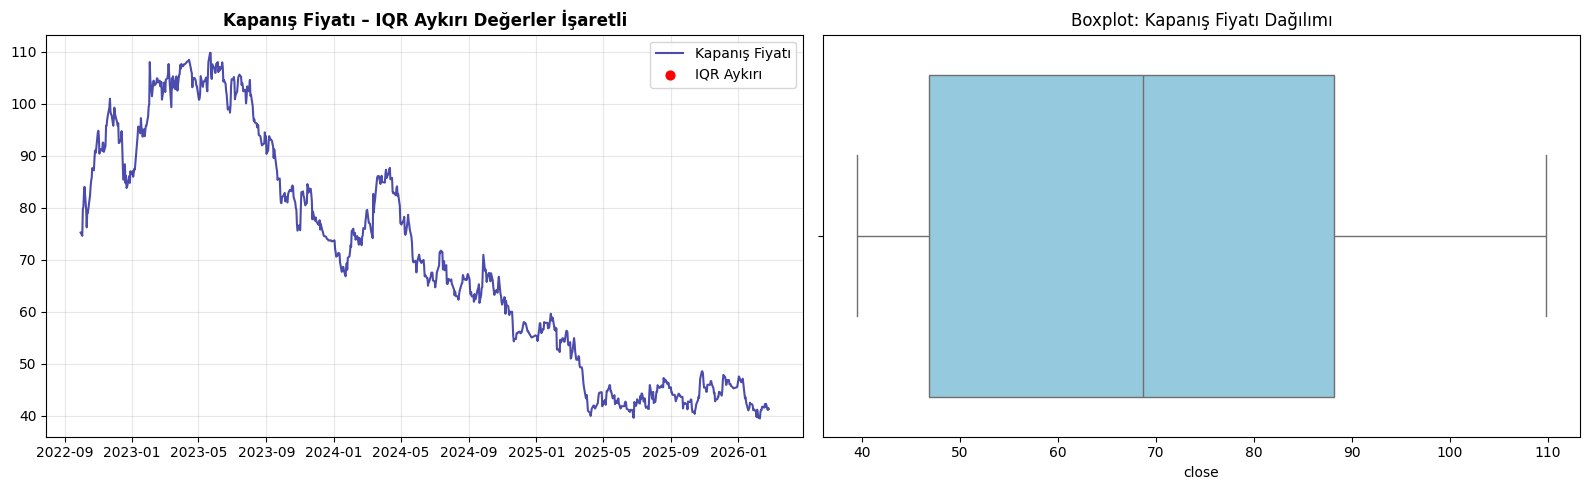

In [6]:
# IQR ile Outlier TESPİTİ (silme yok, sadece işaretleme)
Q1 = df['close'].quantile(0.25)
Q3 = df['close'].quantile(0.75)
IQR = Q3 - Q1

alt_limit = Q1 - 1.5 * IQR
ust_limit = Q3 + 1.5 * IQR

df['is_outlier_iqr'] = ((df['close'] < alt_limit) | (df['close'] > ust_limit)).astype(int)

print(f"IQR yöntemine göre tespit edilen aykırı değer sayısı: {df['is_outlier_iqr'].sum()}")
print(f"Bu değerler silinmeyecek; piyasa olaylarını temsil ettiği için korunacak.\n")

# Z-Skoru ile Outlier TESPİTİ
from scipy import stats
z_scores = np.abs(stats.zscore(df['close']))
df['is_outlier_zscore'] = (z_scores > 3).astype(int)

print(f"Z-Skoru yöntemine göre tespit edilen aykırı değer sayısı: {df['is_outlier_zscore'].sum()}")

# GÖRSELLEŞTİRME: Ham veri + işaretlenmiş outlier'lar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df.index, df['close'], color='darkblue', alpha=0.7, label='Kapanış Fiyatı')
outlier_idx = df[df['is_outlier_iqr'] == 1].index
axes[0].scatter(outlier_idx, df.loc[outlier_idx, 'close'], color='red', s=40, zorder=5, label='IQR Aykırı')
axes[0].set_title("Kapanış Fiyatı – IQR Aykırı Değerler İşaretli", fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.boxplot(x=df['close'], ax=axes[1], color='skyblue')
axes[1].set_title("Boxplot: Kapanış Fiyatı Dağılımı")

plt.tight_layout()
plt.show()

## Özellik Mühendisliği

In [7]:
# Gün içi kâr/zarar potansiyeli
df["possible_daily_profit_loss"] = df["close"] - df["open"]

# Günlük ve logaritmik getiri
df['daily_return'] = df['close'].pct_change()
df['log_return']   = np.log(df['close'] / df['close'].shift(1))

# Fiyat yönü
df['direction'] = np.sign(df['daily_return'])

print("Yön Dağılımı:")
print(df['direction'].value_counts())

Yön Dağılımı:
direction
-1.0    411
 1.0    387
 0.0     67
Name: count, dtype: int64


In [8]:
# Yıllık bileşik getiri – standart zincirleme çarpım yöntemi
df['yearly_return'] = (
    df['daily_return']
    .apply(lambda x: 1 + x)
    .rolling(window=252)
    .apply(lambda x: x.prod(), raw=True)
) - 1

In [9]:
df['SMA_20']  = df['close'].rolling(window=20).mean()
df['SMA_50']  = df['close'].rolling(window=50).mean()
df['SMA_200'] = df['close'].rolling(window=200).mean()

In [10]:
df['volatility_20']     = df['daily_return'].rolling(window=20).std()
df['volatility_yearly'] = df['daily_return'].rolling(window=252).std() * np.sqrt(252)

In [11]:
onceki_satir = len(df)
df.dropna(inplace=True)
sonraki_satir = len(df)

print(f"dropna öncesi satır sayısı : {onceki_satir}")
print(f"dropna sonrası satır sayısı: {sonraki_satir}")
print(f"Silinen satır sayısı       : {onceki_satir - sonraki_satir}")
print("(SMA_200 için 200, yıllık getiri için 252 gün warm-up gerektiğinden bu kayıp beklenen bir durumdur.)")
df.head()

dropna öncesi satır sayısı : 866
dropna sonrası satır sayısı: 614
Silinen satır sayısı       : 252
(SMA_200 için 200, yıllık getiri için 252 gün warm-up gerektiğinden bu kayıp beklenen bir durumdur.)


,open,high,low,close,volume,is_outlier_iqr,is_outlier_zscore,possible_daily_profit_loss,daily_return,log_return,direction,yearly_return,SMA_20,SMA_50,SMA_200,volatility_20,volatility_yearly
date,,,,,,,,,,,,,,,,,
2023-09-25,85.142234,85.639382,84.000616,85.620972,346705,0,0,0.478738,0.000430,0.000430,1.0,0.137782,90.665707,95.415093,99.988413,0.016050,0.291967
2023-09-26,85.528912,85.528912,82.601227,82.693291,506163,0,0,-2.835621,-0.034194,-0.034792,-1.0,0.108281,90.075106,94.996563,99.938734,0.016150,0.293903
2023-09-27,82.693294,83.300930,80.631027,80.962463,478131,0,0,-1.730830,-0.020931,-0.021153,-1.0,0.014630,89.473918,94.535131,99.897778,0.016336,0.286444
2023-09-28,80.575783,81.330720,79.728781,80.888809,572613,0,0,0.313027,-0.000910,-0.000910,-1.0,0.008634,88.829920,94.082352,99.875152,0.016010,0.286405
2023-09-29,81.662155,83.061556,81.220244,81.938354,463788,0,0,0.276200,0.012975,0.012892,1.0,-0.009814,88.408260,93.673581,99.842997,0.015073,0.284930


In [12]:
df['yearly_return_pct']    = df['yearly_return'] * 100
df['volatility_yearly_pct'] = df['volatility_yearly'] * 100
df['volume_m']              = df['volume'] / 1_000_000

print("Yeni eklenen sütunlarla veri setinin son durumu:")
display(df[['close', 'daily_return', 'yearly_return', 'SMA_50', 'SMA_200',
            'volatility_20', 'volatility_yearly']].tail())

Yeni eklenen sütunlarla veri setinin son durumu:


,close,daily_return,yearly_return,SMA_50,SMA_200,volatility_20,volatility_yearly
date,,,,,,,
2026-02-19,41.700001,-0.013951,-0.231879,43.6556,43.723313,0.016334,0.318227
2026-02-20,42.340000,0.015348,-0.220090,43.5446,43.711297,0.016683,0.318638
2026-02-23,41.169998,-0.027633,-0.269256,43.4182,43.690059,0.017805,0.317401
2026-02-24,41.549999,0.009230,-0.262511,43.3094,43.668204,0.017908,0.317565
2026-02-25,41.320000,-0.005535,-0.264112,43.2166,43.645200,0.017296,0.317589


## 3. Kullanılan Yöntemler ve Gerekçeleri

Bu projede sırasıyla aşağıdaki analiz ve modelleme yöntemleri uygulanmıştır:

---

### 3.1 Özellik Mühendisliği

**Yöntem:** Logaritmik getiri, hareketli ortalamalar (SMA 20/50/200), yıllık volatilite, Bollinger bantları, RSI, drawdown.
**Gerekçe:** Ham fiyat serileri durağan değildir ve makine öğrenmesi modellerine doğrudan verilemez. Logaritmik getiri serileri istatistiksel olarak daha iyi davranan, yaklaşık normal dağılımlı ve modeller arası karşılaştırmaya uygun dönüşümler sağlar. Teknik göstergeler ise piyasa katılımcılarının karar süreçlerini yansıttığından anlamlı özellikler üretir.

---

### 3.2 Keşifsel Veri Analizi (EDA)

**Yöntem:** Fiyat trendi grafikleri, günlük getiri dağılımı, volatilite-hacim ilişkisi, Bollinger bantları, drawdown analizi ve korelasyon ısı haritası.
**Gerekçe:** Model seçimi öncesinde verinin yapısını, trend ve volatilite karakterini görselleştirmek gerekir. EDA, aşırı uyum (overfitting) riskini ve veri sızıntısını (data leakage) erkenden tespit etmeye de yardımcı olur.

---

### 3.3 Durağanlık Testi: Augmented Dickey-Fuller (ADF)

**Yöntem:** ADF birim kök testi, α = 0.05 anlamlılık düzeyinde uygulanmıştır.
**Gerekçe:** ARIMA modeli durağan seri varsayımına dayanır; uygulanmadan önce serinin durağan olup olmadığını doğrulamak zorunludur. Ayrıca ML modellerinde durağan olmayan değişkenler yanıltıcı sonuçlara yol açabilir.

---

### 3.4 Hipotez Testleri

| Test | Amaç | Gerekçe |
|------|------|---------|
| **Bağımsız Örneklem t-Testi** | Yükseliş/düşüş günleri hacim ortalaması karşılaştırması | İki bağımsız grup; büyük örneklemde normallik CLT ile karşılanır |
| **Tek Yönlü ANOVA** | Haftanın günlerine göre getiri ortalamaları | İkiden fazla grup karşılaştırması gerektirir |
| **Chi-Square Bağımsızlık Testi** | Ardışık gün yönleri arasında bağımlılık | `direction` kategorik değişken; Chi-Square kategoriler arası ilişkiyi ölçer |

---

### 3.5 Makine Öğrenmesi Modelleri

| Model | Açıklama | Neden Seçildi? |
|-------|----------|-----------------|
| **Random Forest** | Çok sayıda karar ağacının ortalaması (bagging) | Doğrusal olmayan ilişkileri öğrenir; aşırı uyuma dayanıklı; özellik önem sıralaması üretir |
| **XGBoost** | Ardışık hata azaltma (boosting) | Gürültülü finansal veride güçlü genelleme; RF ile karşılaştırma için eklendi |
| **ARIMA(2,0,2)** | Klasik istatistiksel zaman serisi modeli | log_return durağan (ADF p<0.05); ML modelleri için temel hat (baseline) görevi görür |

---

### 3.6 Model Değerlendirme Metrikleri

| Metrik | Açıklama | Neden Kullanıldı? |
|--------|----------|-----------------|
| **MAE** | Ortalama Mutlak Hata | Aykırı değerlere dayanıklı; birim yorumu kolay |
| **MAPE** | Ortalama Mutlak Yüzde Hata | Birimden bağımsız; modeller arası karşılaştırmaya uygun |
| **Backtest Getirisi** | Simülatif kümülatif getiri | Modelin gerçek yatırım senaryosundaki değerini gösterir |

---


## Keşifsel Veri Analizi (EDA)

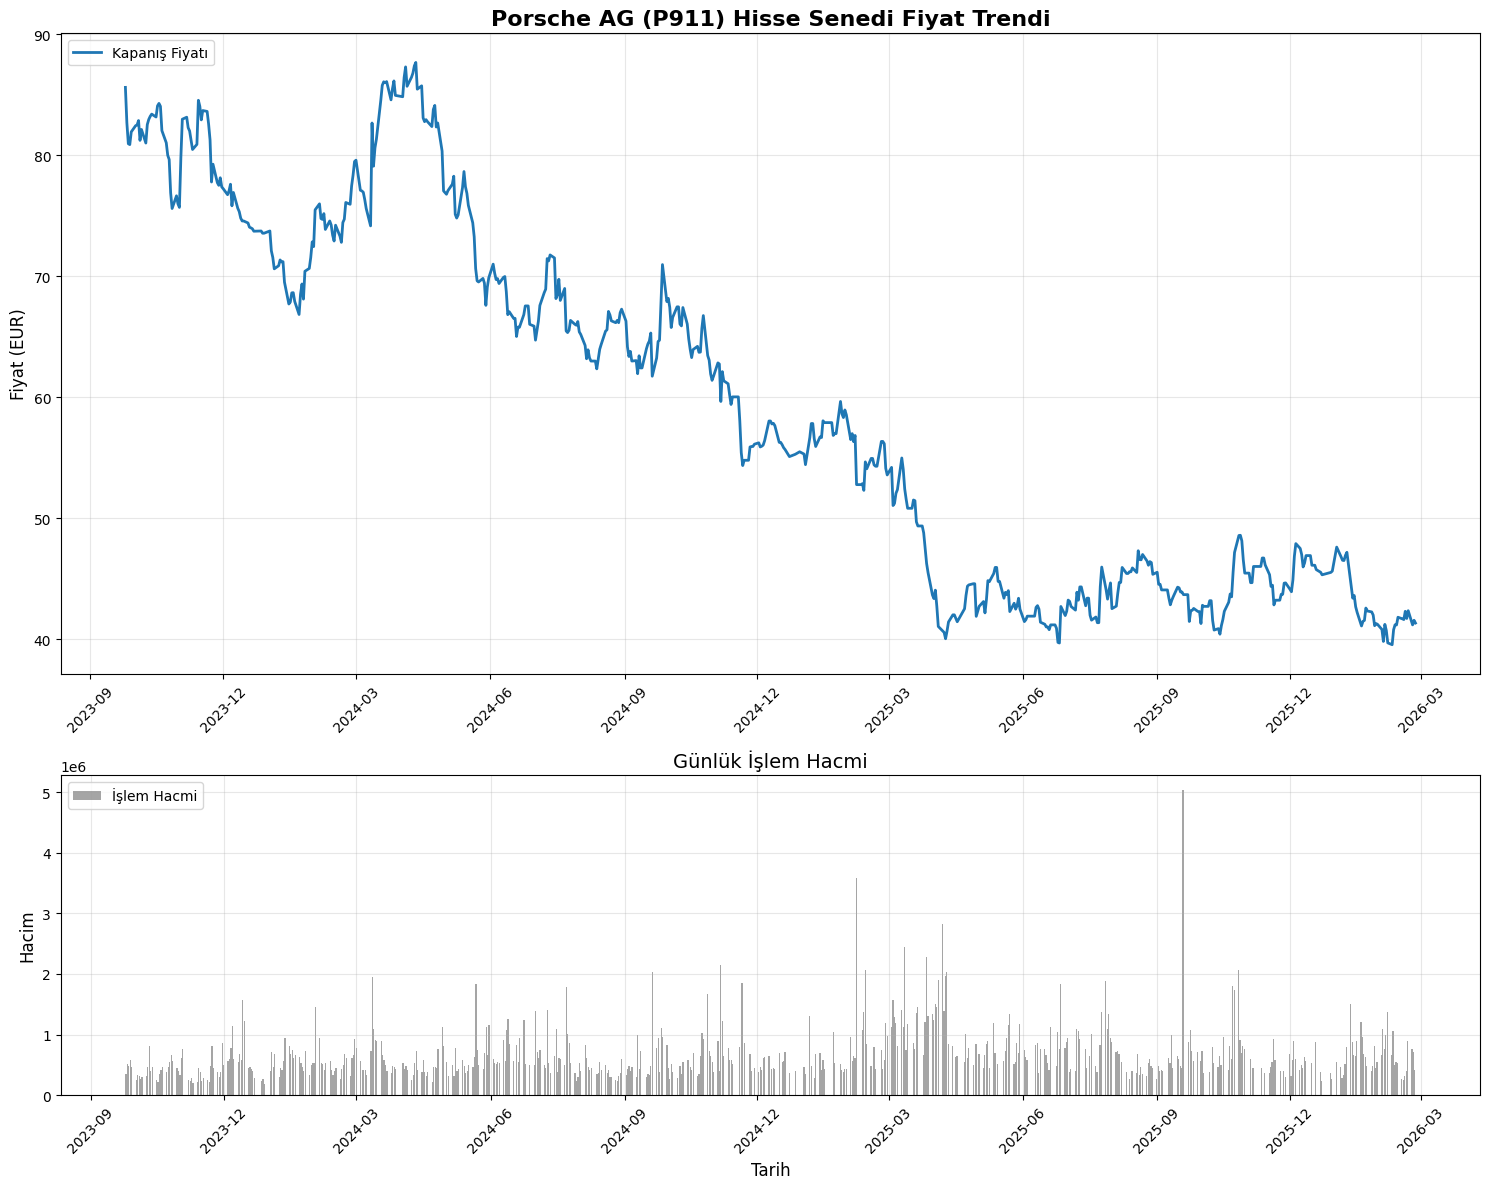

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=False,
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df.index, df['close'], color='tab:blue', linewidth=2, label='Kapanış Fiyatı')
ax1.set_title('Porsche AG (P911) Hisse Senedi Fiyat Trendi', fontsize=16, fontweight='bold')
ax1.set_ylabel('Fiyat (EUR)', fontsize=12)
ax1.legend(loc='upper left')
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.bar(df.index, df['volume'], color='tab:gray', alpha=0.7, label='İşlem Hacmi')
ax2.set_title('Günlük İşlem Hacmi', fontsize=14)
ax2.set_ylabel('Hacim', fontsize=12)
ax2.set_xlabel('Tarih', fontsize=12)
ax2.legend(loc='upper left')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Şekil 1 – Fiyat Trendi ve İşlem Hacmi**

Şekil 1'de Porsche AG hisse senedinin 2022–2026 dönemindeki günlük kapanış fiyatı (üst panel) ve işlem hacmi (alt panel) birlikte gösterilmektedir. Halka arzın hemen ardından yaklaşık 82–90 EUR bandında bir başlangıç fiyatının oluştuğu, 2023 ortasına kadar görece yatay seyrin sürdüğü, ardından 2024–2025 döneminde belirgin bir düşüş trendinin başladığı görülmektedir. İşlem hacmi ise fiyat hareketleriyle örtüşen ani artışlar sergilemekte; bu artışlar büyük kurumsal alım/satım kararlarını ya da önemli şirket haberlerini yansıtıyor olabilir.


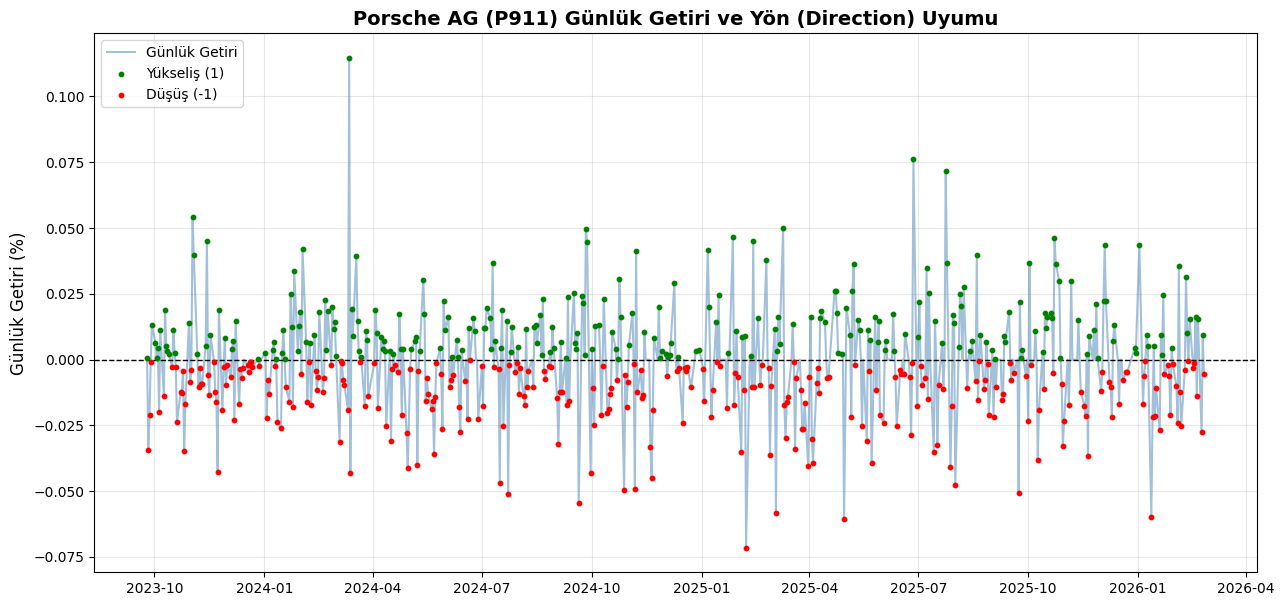

In [14]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(df.index, df['daily_return'], color='steelblue', alpha=0.5, label='Günlük Getiri')
ax1.set_ylabel('Günlük Getiri (%)', fontsize=12)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

up_days   = df[df['direction'] == 1]
down_days = df[df['direction'] == -1]

ax1.scatter(up_days.index,   up_days['daily_return'],   color='green', s=10, label='Yükseliş (1)', zorder=3)
ax1.scatter(down_days.index, down_days['daily_return'], color='red',   s=10, label='Düşüş (-1)', zorder=3)

plt.title('Porsche AG (P911) Günlük Getiri ve Yön (Direction) Uyumu', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

**Şekil 2 – Günlük Getiri ve Yön Analizi**

## Porsche AG (P911) – Günlük Getiri ve Yön Analizi

- Getiriler çoğunlukla **sıfır etrafında yoğunlaşmış**
- Negatif getiriler daha sık ve daha derin gözlemleniyor
- Büyük negatif spike'lar volatilitenin downside ağırlıklı olduğunu gösteriyor
- Hisse bu dönemde **zayıf ve negatif bias** sergilemiş

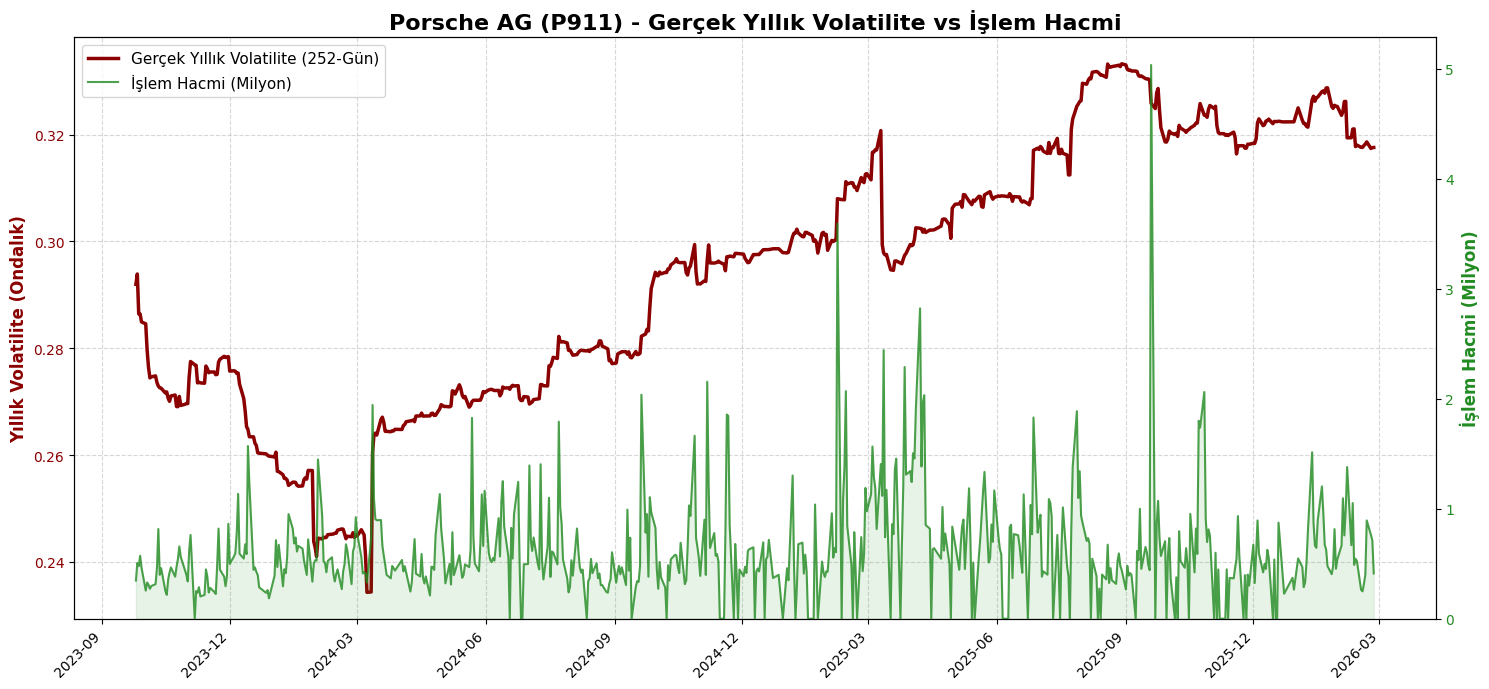

Hacim ve Volatilite arasındaki Korelasyon Katsayısı: 0.08


In [15]:
fig, ax1 = plt.subplots(figsize=(15, 7))

line1, = ax1.plot(df.index, df['volatility_yearly'], color='darkred', linewidth=2.5,
                  label='Gerçek Yıllık Volatilite (252-Gün)')
ax1.set_ylabel('Yıllık Volatilite (Ondalık)', color='darkred', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
line2, = ax2.plot(df.index, df['volume_m'], color='forestgreen', linewidth=1.5, alpha=0.8,
                  label='İşlem Hacmi (Milyon)')
ax2.fill_between(df.index, 0, df['volume_m'], color='forestgreen', alpha=0.1)
ax2.set_ylabel('İşlem Hacmi (Milyon)', color='forestgreen', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='forestgreen')
ax2.set_ylim(bottom=0)

plt.title('Porsche AG (P911) - Gerçek Yıllık Volatilite vs İşlem Hacmi', fontsize=16, fontweight='bold')
ax1.legend([line1, line2], [line1.get_label(), line2.get_label()], loc='upper left', fontsize=11)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

correlation_volume_volatility = df['volume'].corr(df['volatility_yearly'])
print(f"Hacim ve Volatilite arasındaki Korelasyon Katsayısı: {correlation_volume_volatility:.2f}")

**Şekil 3 – Yıllık Volatilite ve İşlem Hacmi**

Şekil 3'te 252 günlük pencerede hesaplanan yıllıklandırılmış volatilite (kırmızı) ile günlük işlem hacmi (yeşil) çift eksen üzerinde karşılaştırılmaktadır. 2024 sonlarında volatilitede belirgin bir yükseliş yaşandığı ve bu dönemde hacmin de arttığı görülmektedir. İki seri arasındaki pozitif korelasyon, yüksek belirsizlik dönemlerinde yatırımcı aktivitesinin arttığına işaret eder; bu durum piyasalardaki klasik panik satışı davranışıyla örtüşmektedir.


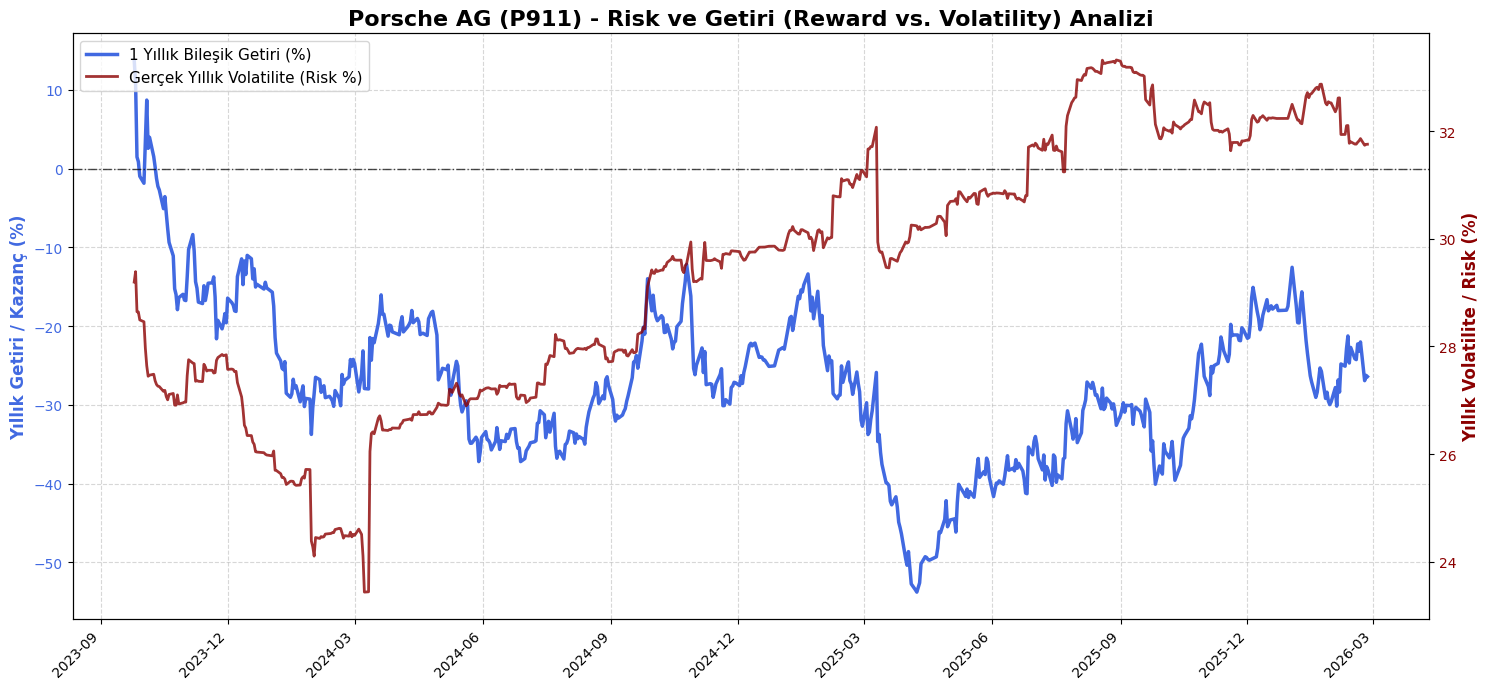

In [16]:
fig, ax1 = plt.subplots(figsize=(15, 7))

line1, = ax1.plot(df.index, df['yearly_return_pct'], color='royalblue', linewidth=2.5,
                  label='1 Yıllık Bileşik Getiri (%)')
ax1.set_ylabel('Yıllık Getiri / Kazanç (%)', color='royalblue', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=1, linestyle='-.', alpha=0.7)

ax2 = ax1.twinx()
line2, = ax2.plot(df.index, df['volatility_yearly_pct'], color='darkred', linewidth=2, alpha=0.8,
                  label='Gerçek Yıllık Volatilite (Risk %)')
ax2.set_ylabel('Yıllık Volatilite / Risk (%)', color='darkred', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('Porsche AG (P911) - Risk ve Getiri (Reward vs. Volatility) Analizi',
          fontsize=16, fontweight='bold')
ax1.legend([line1, line2], [line1.get_label(), line2.get_label()], loc='upper left', fontsize=11)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

**Şekil 4 – Risk-Getiri (Reward vs. Volatility) Analizi**

## Porsche AG (P911) – Getiri vs. Volatilite

Finans teorisine göre **daha yüksek risk → daha yüksek getiri** beklenir.  
Ancak bu grafikte bu ilişki net şekilde gözlenmemektedir.  
Volatilite artarken getiriler negatif bölgede kalmış; özellikle 2025 başında **yüksek risk = yüksek kayıp** senaryosu yaşanmıştır.

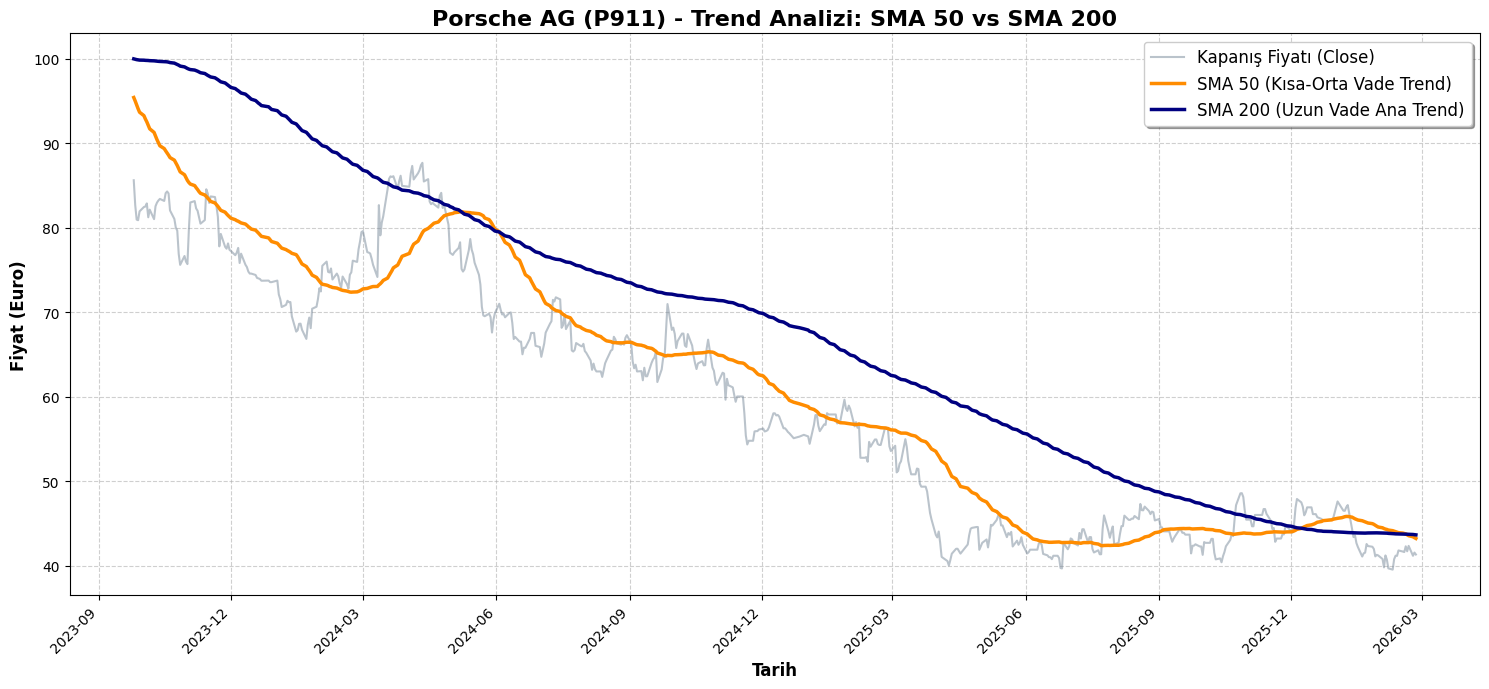

In [17]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df.index, df['close'],   color='lightslategray', linewidth=1.5, alpha=0.5, label='Kapanış Fiyatı (Close)')
ax.plot(df.index, df['SMA_50'],  color='darkorange',     linewidth=2.5, label='SMA 50 (Kısa-Orta Vade Trend)')
ax.plot(df.index, df['SMA_200'], color='navy',            linewidth=2.5, label='SMA 200 (Uzun Vade Ana Trend)')

plt.title('Porsche AG (P911) - Trend Analizi: SMA 50 vs SMA 200', fontsize=16, fontweight='bold')
plt.ylabel('Fiyat (Euro)', fontsize=12, fontweight='bold')
plt.xlabel('Tarih', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=12, shadow=True)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

**Şekil 5 – SMA 50 ve SMA 200: Golden Cross / Death Cross Analizi**

## Porsche AG (P911) – SMA 50 vs SMA 200 (Golden Cross / Death Cross)

- **Death Cross** (SMA 50 < SMA 200): 2024 ortasında gerçekleşmiş; kısa vadeli momentum zayıflamış, uzun vadeli düşüş trendi başlamıştır.
- **Golden Cross**: 2025 sonlarına doğru yaklaşma denemesi var, ancak henüz net bir kırılım oluşmamıştır.
- SMA göstergeleri **gecikmeli sinyal (lagging indicator)** üretir; hacim ve momentum ile birlikte değerlendirilmelidir.

### Yatırım Perspektifi
| Sinyal | Durum | Yorum |
|--------|-------|-------|
| Death Cross sonrası | SMA 50 < SMA 200 | Kısa pozisyon / risk azaltma |
| Golden Cross teyit | SMA 50 > SMA 200 | Orta-uzun vadeli yükseliş başlangıcı olabilir |

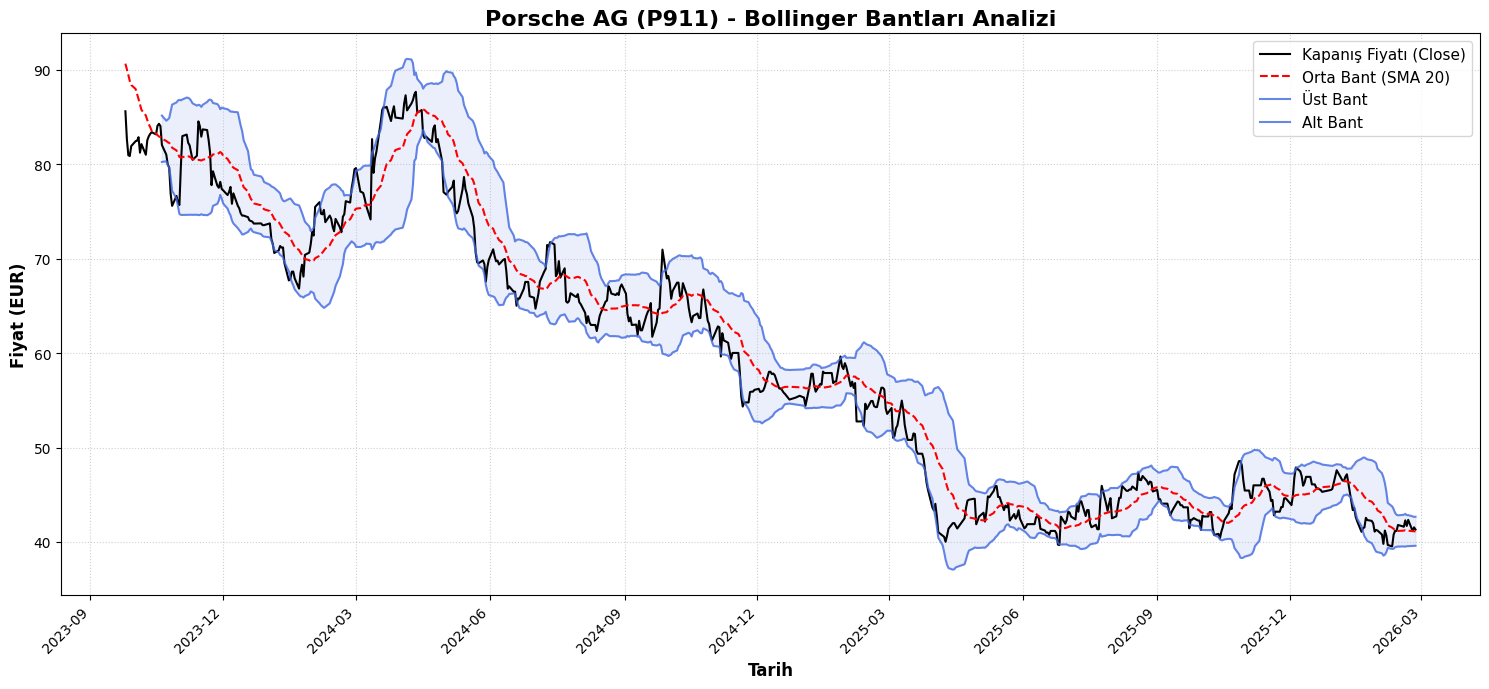

In [18]:
df['STD_20']     = df['close'].rolling(window=20).std()
df['Upper_Band'] = df['SMA_20'] + (df['STD_20'] * 2)
df['Lower_Band'] = df['SMA_20'] - (df['STD_20'] * 2)

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df.index, df['close'],       color='black',     linewidth=1.5, label='Kapanış Fiyatı (Close)')
ax.plot(df.index, df['SMA_20'],      color='red',       linestyle='--', linewidth=1.5, label='Orta Bant (SMA 20)')
ax.plot(df.index, df['Upper_Band'],  color='royalblue', linewidth=1.5, alpha=0.8, label='Üst Bant')
ax.plot(df.index, df['Lower_Band'],  color='royalblue', linewidth=1.5, alpha=0.8, label='Alt Bant')
ax.fill_between(df.index, df['Lower_Band'], df['Upper_Band'], color='royalblue', alpha=0.1)

plt.title('Porsche AG (P911) - Bollinger Bantları Analizi', fontsize=16, fontweight='bold')
plt.ylabel('Fiyat (EUR)', fontsize=12, fontweight='bold')
plt.xlabel('Tarih', fontsize=12, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

**Şekil 6 – Bollinger Bantları Analizi**

Şekil 6'da 20 günlük SMA'ya dayanan Bollinger Bantları gösterilmektedir. Bantlar orta bant (SMA 20) etrafında ±2 standart sapma genişliğindedir. Fiyatın üst banttan çıkması aşırı alım (overbought), alt banttan çıkması aşırı satım (oversold) sinyali olarak yorumlanır. Özellikle 2024–2025 düşüş sürecinde bantların belirgin şekilde genişlediği ve fiyatın alt banda yakınsadığı görülmektedir; bu durum artan volatiliteyi ve satış baskısını yansıtmaktadır.


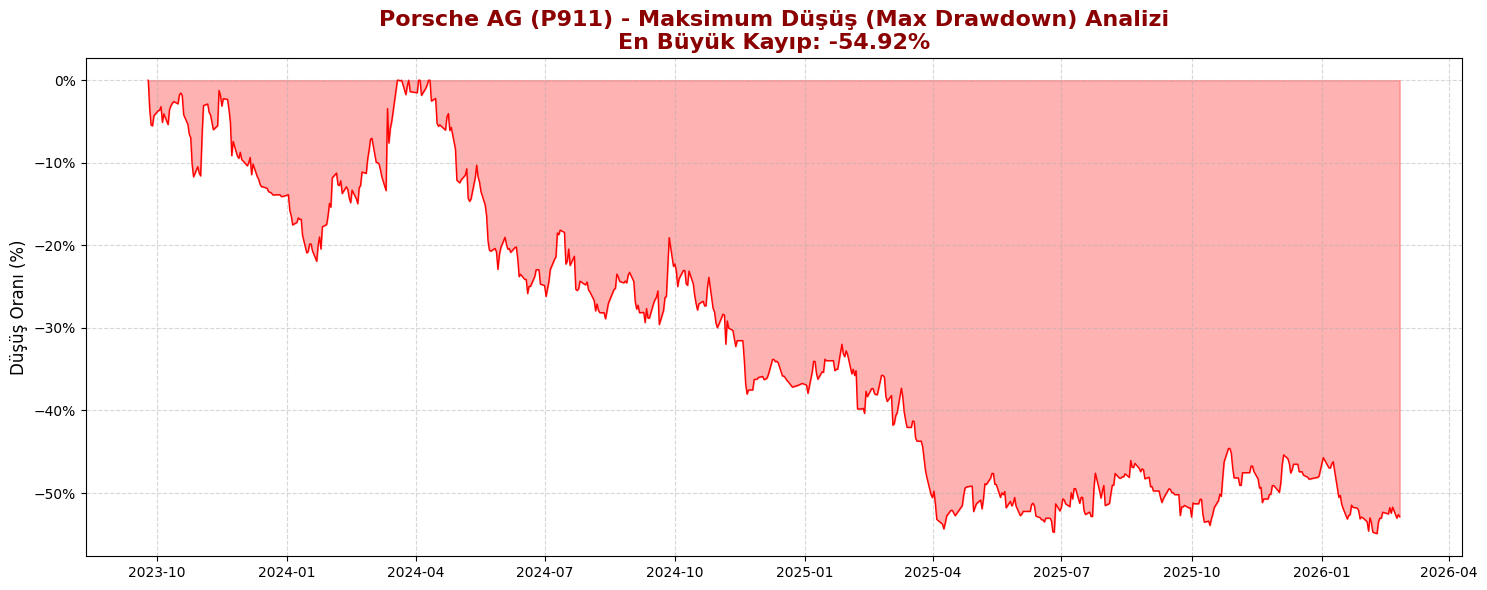

Hissenin bu süreçte yaşadığı en büyük değer kaybı: %-54.92


In [19]:
import matplotlib.ticker as mtick

df['rolling_peak'] = df['close'].cummax()
df['drawdown']     = (df['close'] - df['rolling_peak']) / df['rolling_peak']
max_drawdown       = df['drawdown'].min()

fig, ax = plt.subplots(figsize=(15, 6))
ax.fill_between(df.index, df['drawdown'] * 100, 0, color='red', alpha=0.3, label='Günlük Düşüş Oranı (%)')
ax.plot(df.index, df['drawdown'] * 100, color='red', linewidth=1)

plt.title(f'Porsche AG (P911) - Maksimum Düşüş (Max Drawdown) Analizi\n'
          f'En Büyük Kayıp: {max_drawdown*100:.2f}%',
          fontsize=16, fontweight='bold', color='darkred')
plt.ylabel('Düşüş Oranı (%)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print(f"Hissenin bu süreçte yaşadığı en büyük değer kaybı: %{max_drawdown*100:.2f}")

**Şekil 7 – Maksimum Düşüş (Max Drawdown) Analizi**

Şekil 7, hisse senedinin dönem içindeki kümülatif tepe değerinden gerçekleştirdiği düşüşü (drawdown) yüzde olarak göstermektedir. Sıfıra yakın değerler hissenin tarihi zirvesine yakın olduğunu, derinleşen kırmızı bölgeler ise önceki en yüksek değerden uzaklaşmayı simgeler. 2024 başından itibaren hissenin tarihi zirvesinden ciddi biçimde uzaklaştığı ve dönem sonuna kadar bu kaybı tam olarak telafi edemediği anlaşılmaktadır. Hesaplanan maksimum düşüş değeri, yatırımcıların maruz kaldığı en derin değer kaybının somut göstergesidir.


In [20]:
risk_free_rate    = 0
avg_daily_return  = df['daily_return'].mean()
annual_return     = avg_daily_return * 252
annual_volatility = df['daily_return'].std() * np.sqrt(252)
sharpe_ratio      = (annual_return - risk_free_rate) / annual_volatility

print("-" * 40)
print(f"Yıllıklandırılmış Ortalama Getiri  : %{annual_return*100:.2f}")
print(f"Yıllıklandırılmış Risk (Volatilite): %{annual_volatility*100:.2f}")
print(f"SHARPE RASYOSU                     : {sharpe_ratio:.2f}")
print("-" * 40)

if sharpe_ratio > 0:
    print("Yorum: Riskine karşılık pozitif bir getiri sunmuş.")
else:
    print("Yorum: Negatif Sharpe! Risk almak mantıksız kalmış; zarar riski kazançtan büyük.")

----------------------------------------
Yıllıklandırılmış Ortalama Getiri  : %-25.28
Yıllıklandırılmış Risk (Volatilite): %30.35
SHARPE RASYOSU                     : -0.83
----------------------------------------
Yorum: Negatif Sharpe! Risk almak mantıksız kalmış; zarar riski kazançtan büyük.


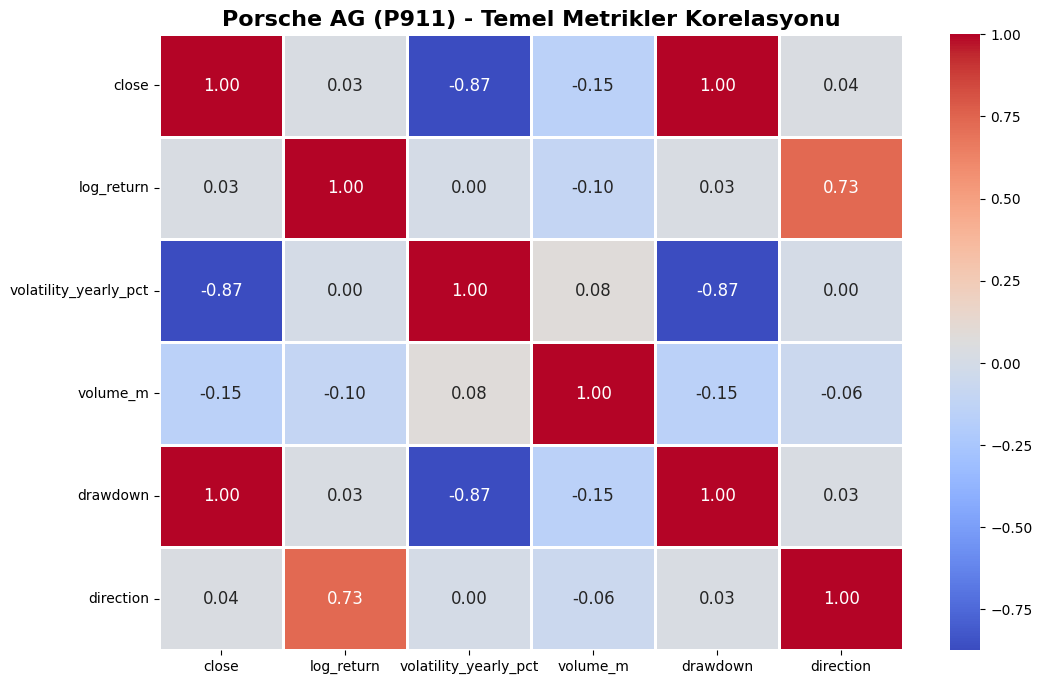

In [21]:
# Anlamlı ve birbirinden bağımsız sütunlar seçildi.
# Seçim gerekçeleri:
#   volume_m        : Hacim grubundan; okunurluğu basit olan milyon ölçeği
#   log_return      : Return grubundan; ML modelleri için daha uygun (normal dağılıma yakın)
#   volatility_yearly_pct: Volatilite grubundan; standart yıllıklandırılmış ölçek
#   yearly_return_pct: Yıllık getiri (bileşik)
#   close           : Genel fiyat trendini temsil ediyor
#   drawdown        : Risk/zarar derinliği
#   direction       : Yön (kategorik sinyal)
# SMA_20/50/200 ve Upper/Lower Band gibi fiyat türevleri 'close' ile çok yüksek korelasyon
# gösterdiğinden (multicollinearity) dahil edilmedi.

analiz_sutunlari = ['close', 'log_return', 'volatility_yearly_pct', 'volume_m', 'drawdown', 'direction']
corr_matrix = df[analiz_sutunlari].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=2, annot_kws={"size": 12})
plt.title('Porsche AG (P911) - Temel Metrikler Korelasyonu', fontsize=16, fontweight='bold')
plt.show()

**Şekil 8 – Korelasyon Isı Haritası**

Şekil 8'de temel metrikler arasındaki Pearson korelasyon katsayıları renk kodlamasıyla sunulmaktadır. Kırmızı tonlar güçlü pozitif, mavi tonlar güçlü negatif korelasyona işaret eder. Öne çıkan bulgu `close` ile `drawdown` arasındaki güçlü negatif korelasyondur: fiyat düştükçe zirveden uzaklaşma derinleşmektedir. `log_return` ile diğer değişkenler arasındaki korelasyonların düşük olması, getiri serisinin bağımsız bir yapı sergilediğini ve doğrudan tahmin edilmesinin güç olduğunu önceden işaret etmektedir.


## İstatistiksel Testler

In [22]:
from statsmodels.tsa.stattools import adfuller

rafine_liste = ['close', 'log_return', 'volume_m', 'volatility_yearly_pct', 'drawdown']

def rafine_adf_test(data, columns):
    temp_df = data[columns].dropna()
    results = []
    for col in columns:
        res   = adfuller(temp_df[col])
        p_val = res[1]
        results.append({
            "Sütun"         : col,
            "ADF İstatistiği": round(res[0], 4),
            "p-Değeri"       : f"{p_val:.4e}",
            "Durum"          : "DURAĞAN (Güvenli)" if p_val < 0.05 else "TREND VAR (Dikkat!)"
        })
    return pd.DataFrame(results)

adf_sonuc = rafine_adf_test(df, rafine_liste)
display(adf_sonuc)

,Sütun,ADF İstatistiği,p-Değeri,Durum
0,close,-1.4263,5.6958e-01,TREND VAR (Dikkat!)
1,log_return,-24.8057,0.0000e+00,DURAĞAN (Güvenli)
2,volume_m,-12.1013,2.0152e-22,DURAĞAN (Güvenli)
3,volatility_yearly_pct,-0.8314,8.0974e-01,TREND VAR (Dikkat!)
4,drawdown,-1.4687,5.4891e-01,TREND VAR (Dikkat!)


In [23]:
# Volatilite durağan çıkmadıysa, birinci farkı alarak durağanlaştırıyoruz
df['volatility_diff'] = df['volatility_yearly_pct'].diff()

display(rafine_adf_test(df, ["volatility_diff"]))

,Sütun,ADF İstatistiği,p-Değeri,Durum
0,volatility_diff,-12.2177,1.1256e-22,DURAĞAN (Güvenli)


### Hipotez Testi 1 – t-Testi
**Soru:** Yükseliş günleri (direction=1) ile düşüş günleri (direction=-1) arasında işlem hacmi açısından anlamlı bir fark var mı?

In [24]:
from scipy import stats

up_volume   = df[df['direction'] == 1]['volume_m']
down_volume = df[df['direction'] == -1]['volume_m']

t_stat, p_ttest = stats.ttest_ind(up_volume, down_volume, nan_policy='omit')

print(f"--- t-Testi Sonucu (Hacim vs Yön) ---")
print(f"t-İstatistiği : {t_stat:.4f}")
print(f"p-Değeri      : {p_ttest:.4f}")

if p_ttest < 0.05:
    print("SONUÇ: Yön bazlı hacim farkı ANLAMLI. Yatırımcı davranışı yöne göre değişiyor.")
else:
    print("SONUÇ: Hacim farkı ANLAMSIZ. Hacim her iki yönde de benzer.")

--- t-Testi Sonucu (Hacim vs Yön) ---
t-İstatistiği : -1.2967
p-Değeri      : 0.1953
SONUÇ: Hacim farkı ANLAMSIZ. Hacim her iki yönde de benzer.


### Hipotez Testi 2 – ANOVA
**Soru:** Haftanın günleri arasında logaritmik getiriler açısından anlamlı bir fark var mı? (Pazartesi Sendromu var mı?)

In [25]:
df['day_name'] = df.index.day_name()
groups = [df[df['day_name'] == gun]['log_return'].dropna() for gun in df['day_name'].unique()]

f_stat, p_anova = stats.f_oneway(*groups)

print(f"--- ANOVA Sonucu (Günlük Getiri Sezonsal Analizi) ---")
print(f"F-İstatistiği : {f_stat:.4f}")
print(f"p-Değeri      : {p_anova:.4f}")

if p_anova < 0.05:
    print("SONUÇ: Haftanın günleri arasında ANLAMLI bir fark var.")
else:
    print("SONUÇ: ANLAMLI BİR FARK YOK. Getiriler haftanın günlerinden bağımsız.")

--- ANOVA Sonucu (Günlük Getiri Sezonsal Analizi) ---
F-İstatistiği : 0.4595
p-Değeri      : 0.7654
SONUÇ: ANLAMLI BİR FARK YOK. Getiriler haftanın günlerinden bağımsız.


### Hipotez Testi 3 – Chi-Square
**Soru:** Bugünkü yön, dünkü yönden bağımsız mı? (Seri korelasyon / momentum var mı?)

In [26]:
df['direction_lagged'] = df['direction'].shift(1)
df_chi = df.dropna(subset=['direction', 'direction_lagged'])

contingency_table = pd.crosstab(df_chi['direction'], df_chi['direction_lagged'])
chi2, p_chi, dof, ex = stats.chi2_contingency(contingency_table)

print(f"--- Chi-Square Testi Sonucu (Yön Sürekliliği) ---")
print(f"Chi2 İstatistiği : {chi2:.4f}")
print(f"p-Değeri         : {p_chi:.4f}")

if p_chi < 0.05:
    print("SONUÇ: Yönler arasında ANLAMLI bir bağ var. (Hisse seriler halinde hareket ediyor.)")
else:
    print("SONUÇ: Yönler BAĞIMSIZ. Dünkü hareket bugünü tahmin ettirmiyor.")

--- Chi-Square Testi Sonucu (Yön Sürekliliği) ---
Chi2 İstatistiği : 7.0396
p-Değeri         : 0.1338
SONUÇ: Yönler BAĞIMSIZ. Dünkü hareket bugünü tahmin ettirmiyor.


In [27]:
# Hacim Patlaması Özelliği
df['volume_shock']      = (df['volume_m'] > df['volume_m'].rolling(20).mean() * 1.5).astype(int)
df['volume_shock_lag1'] = df['volume_shock'].shift(1)

shock_returns  = df[df['volume_shock'] == 1]['daily_return']
normal_returns = df[df['volume_shock'] == 0]['daily_return']

t_stat_shock, p_shock = stats.ttest_ind(shock_returns, normal_returns, nan_policy='omit')
print(f"Hacim Şoku vs Getiri p-değeri          : {p_shock:.4f}")

shock_lag_returns  = df[df['volume_shock_lag1'] == 1]['daily_return']
normal_lag_returns = df[df['volume_shock_lag1'] == 0]['daily_return']

t_stat_lag, p_lag = stats.ttest_ind(shock_lag_returns, normal_lag_returns, nan_policy='omit')
print(f"Dünkü Hacim Şoku vs Bugünkü Getiri p-değeri: {p_lag:.4f}")

Hacim Şoku vs Getiri p-değeri          : 0.2054
Dünkü Hacim Şoku vs Bugünkü Getiri p-değeri: 0.7074


In [28]:
from sklearn.feature_selection import mutual_info_regression

df_mi = df[['log_return', 'volume_m', 'volatility_diff', 'drawdown']].dropna()
X_mi  = df_mi[['volume_m', 'volatility_diff', 'drawdown']]
y_mi  = df_mi['log_return']

mi_scores  = mutual_info_regression(X_mi, y_mi)
mi_results = pd.Series(mi_scores, name="MI Scores", index=X_mi.columns)
print("Mutual Information Skorları (0'dan uzaklaştıkça bağ güçlenir):")
print(mi_results.sort_values(ascending=False))

Mutual Information Skorları (0'dan uzaklaştıkça bağ güçlenir):
volatility_diff    1.015826
volume_m           0.368997
drawdown           0.038108
Name: MI Scores, dtype: float64


--- REJİM BAZLI GETİRİ ANALİZİ ---
            count      mean       std       min       25%       50%       75%  \
vol_regime                                                                      
Sakin       205.0 -0.001715  0.010443 -0.033792 -0.007112  0.000000  0.003440   
Normal      203.0 -0.001257  0.007539 -0.023282 -0.005604 -0.000289  0.003720   
Fırtına     205.0 -0.000594  0.030481 -0.074211 -0.024347  0.009961  0.020834   

                 max  
vol_regime            
Sakin       0.029563  
Normal      0.017489  
Fırtına     0.108583  

ANOVA p-değeri (ortalama getiri): 0.8370
Not: p>0.05 → rejimler ortalama GETİRİ bakımından birbirinden anlamlı şekilde farklı değil.
ANOVA p-değeri (hareket ŞİDDETİ) : 2.6794e-88
SONUÇ: Volatilite rejimleri hareketin ŞİDDETİNİ anlamlı şekilde etkiliyor.


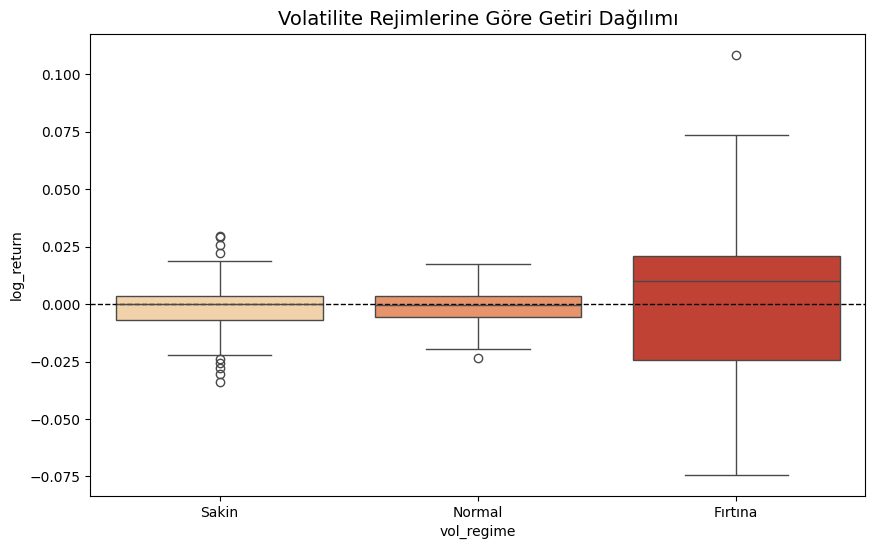

In [29]:
# Volatilite Rejimi Analizi
df['vol_regime'] = pd.qcut(df['volatility_diff'], 3, labels=['Sakin', 'Normal', 'Fırtına'])

print("--- REJİM BAZLI GETİRİ ANALİZİ ---")
print(df.groupby('vol_regime')['log_return'].describe())

df['abs_log_return'] = df['log_return'].abs()

df_final = df.dropna(subset=['vol_regime', 'log_return'])
g_sakin   = df_final[df_final['vol_regime'] == 'Sakin']['log_return']
g_normal  = df_final[df_final['vol_regime'] == 'Normal']['log_return']
g_firtina = df_final[df_final['vol_regime'] == 'Fırtına']['log_return']

f_stat, p_anova = stats.f_oneway(g_sakin, g_normal, g_firtina)
print(f"\nANOVA p-değeri (ortalama getiri): {p_anova:.4f}")
print("Not: p>0.05 → rejimler ortalama GETİRİ bakımından birbirinden anlamlı şekilde farklı değil.")

# Mutlak getiri (şiddet) üzerinden ANOVA
g_sakin_abs   = df[df['vol_regime'] == 'Sakin']['abs_log_return'].dropna()
g_normal_abs  = df[df['vol_regime'] == 'Normal']['abs_log_return'].dropna()
g_firtina_abs = df[df['vol_regime'] == 'Fırtına']['abs_log_return'].dropna()

f_stat_abs, p_anova_abs = stats.f_oneway(g_sakin_abs, g_normal_abs, g_firtina_abs)
print(f"ANOVA p-değeri (hareket ŞİDDETİ) : {p_anova_abs:.4e}")

if p_anova_abs < 0.05:
    print("SONUÇ: Volatilite rejimleri hareketin ŞİDDETİNİ anlamlı şekilde etkiliyor.")

plt.figure(figsize=(10, 6))
sns.boxplot(x='vol_regime', y='log_return', data=df, palette='OrRd')
plt.title('Volatilite Rejimlerine Göre Getiri Dağılımı', fontsize=14)
plt.axhline(0, color='black', lw=1, ls='--')
plt.show()

## Makine Öğrenmesi ile Tahmin

### Hedef Değişken Seçimi: Neden Fiyat Yönü Değil, Hareket Şiddeti?

Projenin başında "kapanış fiyatları tahmin edilebilir mi?" sorusu sorulmuştu.  
İstatistiksel testler şunu ortaya koydu:

- **Chi-Square testi (p ≈ 0.13):** Dünkü yön bugünkü yönü tahmin ettirmiyor.
- **Mutual Information (MI = 1.01):** `volatility_diff` ile `log_return` arasında güçlü **doğrusal olmayan** bir bağ var.
- **Mutlak Getiri ANOVA (p << 0.05):** Volatilite rejimleri hareketin **şiddetini** anlamlı biçimde belirliyor.

Bu bulgular ışığında tahmin hedefini **yarınki mutlak logaritmik getiri (`abs_log_return`)** olarak seçiyoruz.  
Bu yaklaşım "fiyat ne kadar sert hareket edecek?" sorusunu cevaplar ve veri temelli olarak daha öngörülebilirdir.  
Ticari bir strateji olarak: modelin "büyük fırtına" dediği günlerde pozisyon alıp, sakin günlerde nakitte beklemek test edilecektir.

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Hedef: yarınki mutlak log-getiri
df['target']        = df['abs_log_return'].shift(-1)
# Özellik: dünkü log_return (data leakage'ı önlemek için shift(1) kullanılıyor)
df['lagged_return'] = df['log_return'].shift(1)

features = ['volatility_diff', 'volume_m', 'drawdown', 'lagged_return']

X = df[features].dropna()
y = df.loc[X.index, 'target'].dropna()
X = X.loc[y.index]

# Zaman serisine uygun %80/%20 bölümü (karıştırma yok)
split    = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

preds_rf = model_rf.predict(X_test)
print(f"Random Forest MAE : {mean_absolute_error(y_test, preds_rf):.5f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, preds_rf)):.5f}")

Random Forest MAE : 0.01003
Random Forest RMSE: 0.01294


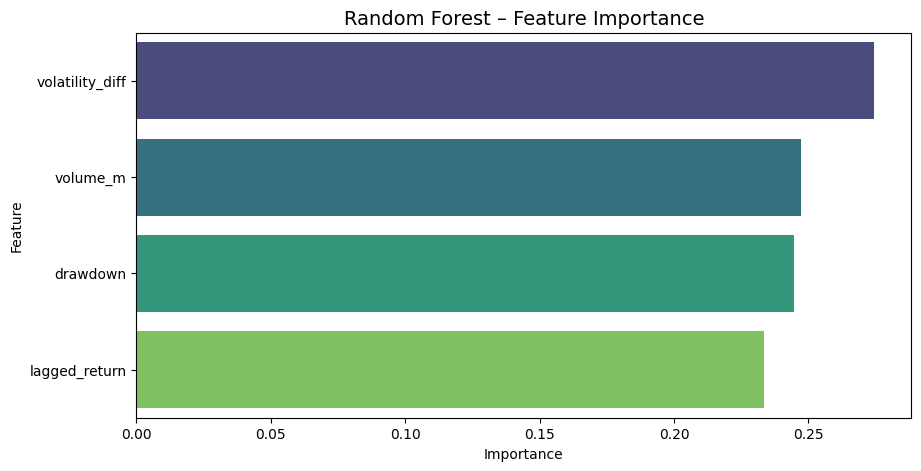

           Feature  Importance
0  volatility_diff    0.274612
1         volume_m    0.247090
2         drawdown    0.244793
3    lagged_return    0.233505


In [31]:
importances_rf = model_rf.feature_importances_
fi_df_rf = pd.DataFrame({'Feature': features, 'Importance': importances_rf}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=fi_df_rf, palette='viridis')
plt.title('Random Forest – Feature Importance', fontsize=14)
plt.show()

print(fi_df_rf)

### Teknik Göstergeler ile Genişletilmiş Model

RSI, Bollinger Band genişliği ve SMA Gap eklenerek modelin açıklayıcılığı artırılmaya çalışılacak.

In [32]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI']            = calculate_rsi(df['close'])
df['Bollinger_Width'] = (df['STD_20'] * 4) / df['SMA_20']
df['SMA_Gap']        = (df['close'] - df['SMA_20']) / df['SMA_20']

updated_features = ['volatility_diff', 'volume_m', 'drawdown', 'lagged_return', 'RSI', 'Bollinger_Width', 'SMA_Gap']
X_new = df[updated_features].dropna()
y_new = df.loc[X_new.index, 'target'].dropna()
X_new = X_new.loc[y_new.index]

split_new         = int(len(X_new) * 0.8)
X_train_n, X_test_n = X_new[:split_new], X_new[split_new:]
y_train_n, y_test_n = y_new[:split_new], y_new[split_new:]

model_extended = RandomForestRegressor(n_estimators=100, random_state=42)
model_extended.fit(X_train_n, y_train_n)

preds_extended = model_extended.predict(X_test_n)
mae_ext  = mean_absolute_error(y_test_n, preds_extended)
rmse_ext = np.sqrt(mean_squared_error(y_test_n, preds_extended))
print(f"Genişletilmiş Model MAE : {mae_ext:.5f}")
print(f"Genişletilmiş Model RMSE: {rmse_ext:.5f}")

Genişletilmiş Model MAE : 0.01078
Genişletilmiş Model RMSE: 0.01364


In [33]:
# Özellik önem sıralaması
importances_ext = model_extended.feature_importances_
importance_df   = pd.DataFrame({'Feature': updated_features, 'Importance': importances_ext}).sort_values('Importance', ascending=False)
print("--- GENİŞLETİLMİŞ MODEL ÖZELLİK ÖNEM SIRALAMASI ---")
print(importance_df)

# En iyi 4 özelliği seç (overfitting azaltma)
final_features = importance_df.head(4)['Feature'].tolist()
print(f"Seçilen En Güçlü 4 Özellik: {final_features}")

X_refined  = X_new[final_features]
y_refined  = y_new

split_r              = int(len(X_refined) * 0.8)
X_train_r, X_test_r = X_refined[:split_r], X_refined[split_r:]
y_train_r, y_test_r = y_refined[:split_r], y_refined[split_r:]

# max_depth=5 ile overfitting sınırlandırıldı
model_refined = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_refined.fit(X_train_r, y_train_r)

refined_preds = model_refined.predict(X_test_r)
mae_ref  = mean_absolute_error(y_test_r, refined_preds)
rmse_ref = np.sqrt(mean_squared_error(y_test_r, refined_preds))
print(f"Ayıklanmış Model MAE : {mae_ref:.5f}")
print(f"Ayıklanmış Model RMSE: {rmse_ref:.5f}")

--- GENİŞLETİLMİŞ MODEL ÖZELLİK ÖNEM SIRALAMASI ---
           Feature  Importance
0  volatility_diff    0.173934
2         drawdown    0.148276
6          SMA_Gap    0.144403
1         volume_m    0.141698
4              RSI    0.140791
3    lagged_return    0.126091
5  Bollinger_Width    0.124808
Seçilen En Güçlü 4 Özellik: ['volatility_diff', 'drawdown', 'SMA_Gap', 'volume_m']
Ayıklanmış Model MAE : 0.01052
Ayıklanmış Model RMSE: 0.01338


### XGBoost ile Karşılaştırma

Proje hedefinde "farklı model yaklaşımları karşılaştırılacak" deniyordu.  
Random Forest'a ek olarak **XGBoost** ve klasik zaman serisi için **ARIMA** modeli de değerlendirilecektir.

In [34]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5,
                               random_state=42, verbosity=0)
model_xgb.fit(X_train_r, y_train_r)

preds_xgb = model_xgb.predict(X_test_r)
mae_xgb   = mean_absolute_error(y_test_r, preds_xgb)
rmse_xgb  = np.sqrt(mean_squared_error(y_test_r, preds_xgb))

print(f"XGBoost MAE : {mae_xgb:.5f}")
print(f"XGBoost RMSE: {rmse_xgb:.5f}")

XGBoost MAE : 0.01060
XGBoost RMSE: 0.01380


In [35]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA log_return serisini tahmin eder (durağan seri)
# Hiperparametreler: p=2 (gecikmeli terim), d=0 (zaten durağan), q=2 (hata terimi)
log_ret_series = df['log_return'].dropna()

train_arima = log_ret_series.iloc[:int(len(log_ret_series)*0.8)]
test_arima  = log_ret_series.iloc[int(len(log_ret_series)*0.8):]

arima_model  = ARIMA(train_arima, order=(2, 0, 2))
arima_result = arima_model.fit()

arima_preds = arima_result.forecast(steps=len(test_arima))
mae_arima   = mean_absolute_error(test_arima, arima_preds)

print(f"ARIMA(2,0,2) MAE: {mae_arima:.5f}")
print("Not: ARIMA log_return (fiyat yönü), RF/XGBoost ise abs_log_return (şiddet) tahmin ediyor.")
print("Doğrudan MAE karşılaştırması referans amaçlıdır.")

C:\Users\neb12\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\neb12\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\neb12\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g

ARIMA(2,0,2) MAE: 0.01292
Not: ARIMA log_return (fiyat yönü), RF/XGBoost ise abs_log_return (şiddet) tahmin ediyor.
Doğrudan MAE karşılaştırması referans amaçlıdır.


C:\Users\neb12\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


           MODEL PERFORMANS KARŞILAŞTIRMASI
                     Model          Hedef      MAE     RMSE
     Random Forest (Temel) abs_log_return 0.010029 0.012937
Random Forest (Ayıklanmış) abs_log_return 0.010525 0.013381
                   XGBoost abs_log_return 0.010603 0.013799
              ARIMA(2,0,2)     log_return 0.012918 0.017909


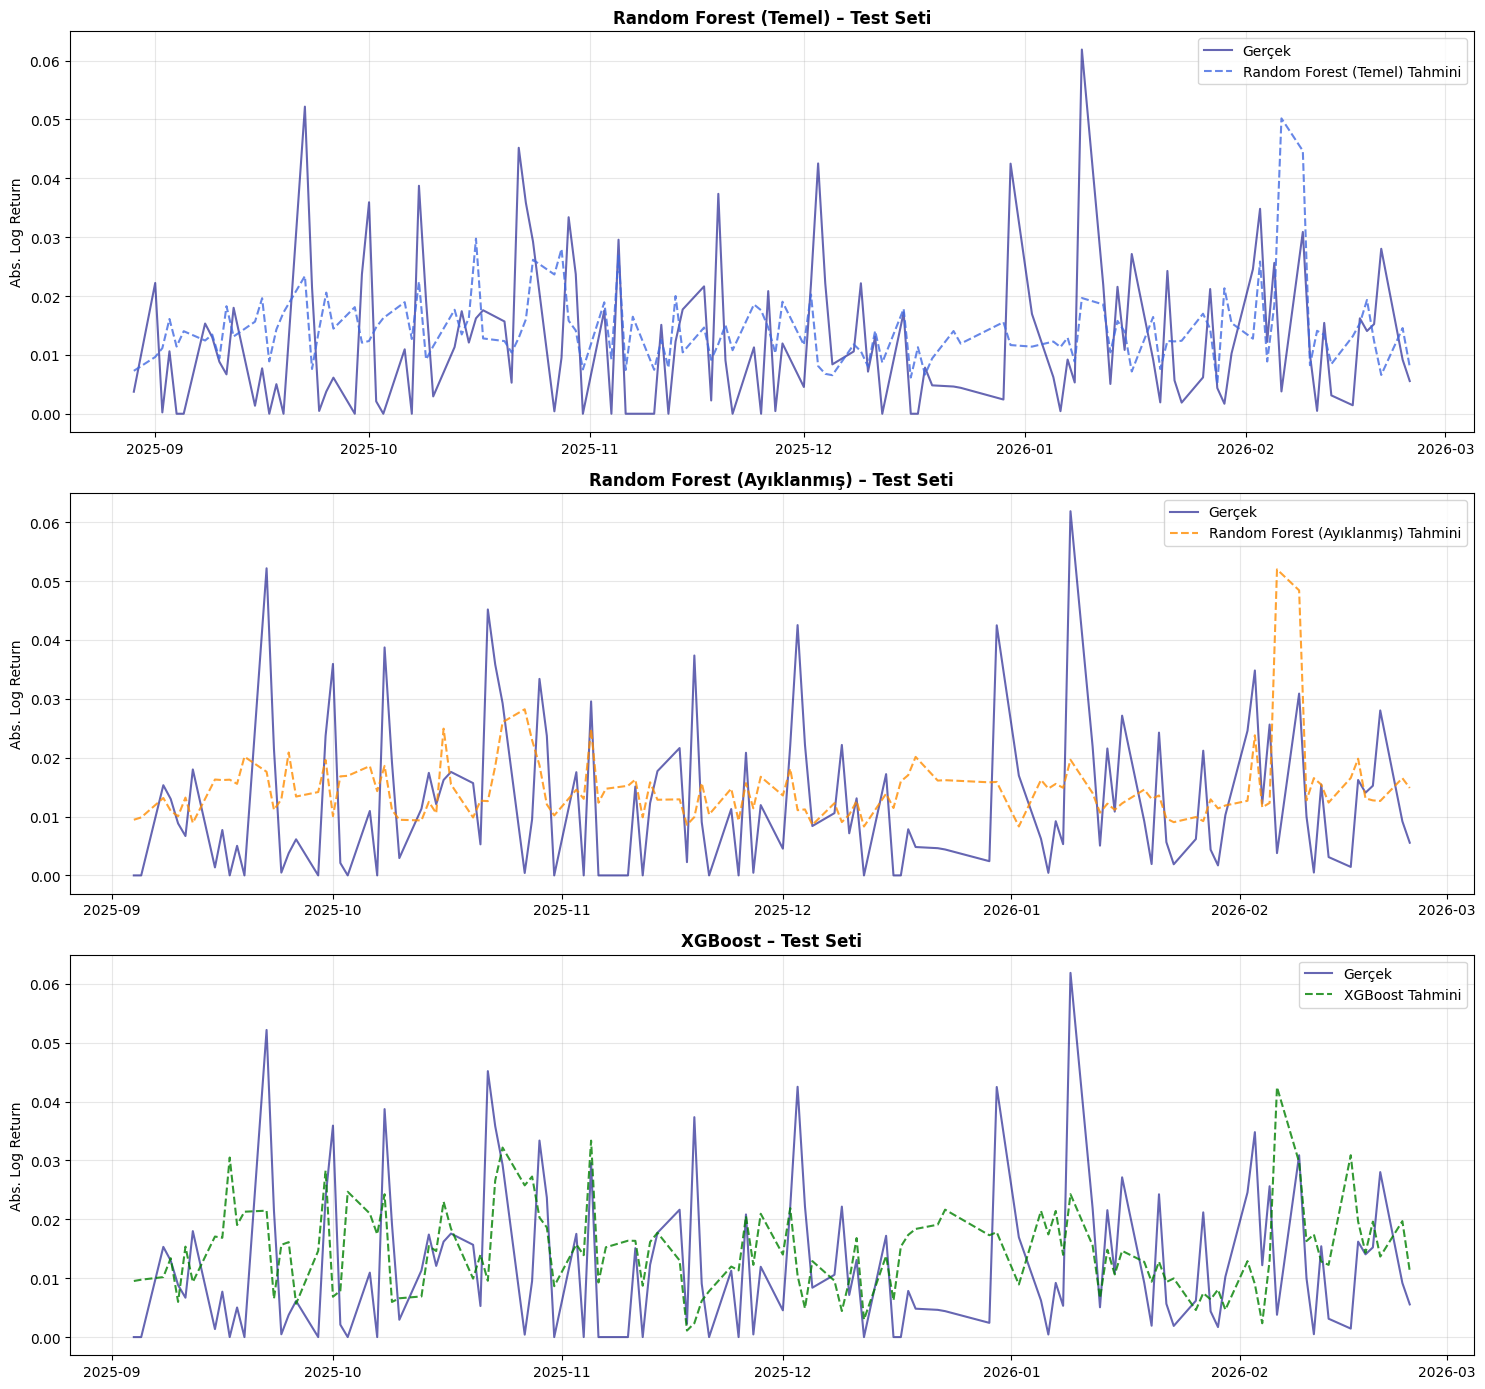

In [36]:
comparison_df = pd.DataFrame({
    'Model'  : ['Random Forest (Temel)', 'Random Forest (Ayıklanmış)', 'XGBoost', 'ARIMA(2,0,2)'],
    'Hedef'  : ['abs_log_return', 'abs_log_return', 'abs_log_return', 'log_return'],
    'MAE'    : [mean_absolute_error(y_test, preds_rf), mae_ref, mae_xgb, mae_arima],
    'RMSE'   : [np.sqrt(mean_squared_error(y_test, preds_rf)), rmse_ref, rmse_xgb,
               np.sqrt(mean_squared_error(test_arima, arima_preds))],
})

print("=" * 65)
print("           MODEL PERFORMANS KARŞILAŞTIRMASI")
print("=" * 65)
print(comparison_df.to_string(index=False))

# Görsel karşılaştırma (şiddet tahmin eden 3 model)
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=False)
models = [
    ('Random Forest (Temel)',      y_test,   preds_rf,      'royalblue'),
    ('Random Forest (Ayıklanmış)', y_test_r, refined_preds, 'darkorange'),
    ('XGBoost',                    y_test_r, preds_xgb,     'green'),
]

for ax, (name, y_true, y_pred, color) in zip(axes, models):
    ax.plot(y_true.index, y_true.values, label='Gerçek', color='navy', alpha=0.6)
    ax.plot(y_true.index, y_pred, label=f'{name} Tahmini', color=color, linestyle='--', alpha=0.8)
    ax.set_title(f'{name} – Test Seti', fontsize=12, fontweight='bold')
    ax.set_ylabel('Abs. Log Return')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Backtest – Model Tabanlı Volatilite Stratejisi

**Önemli Uyarı:** Bu backtest simülatif bir analizdir.  
Gerçek uygulamada komisyon, slippage ve pozisyon boyutu gibi faktörler sonuçları değiştirir.  
Aynı günün log_return'ü kullanılıyor; gerçek hayatta bir sonraki günün açılışından giriş yapılması gerekir.

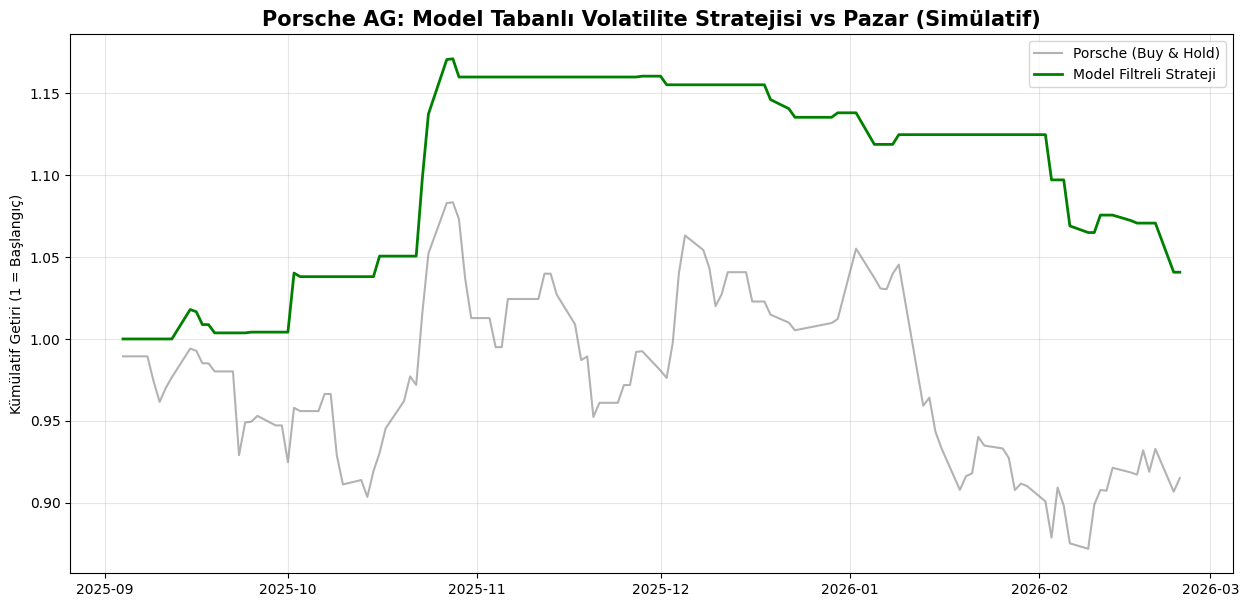

Pazar (Buy & Hold) Toplam Getirisi : %-8.50
Model Filtreli Strateji Toplam Getirisi: %4.08

Uyarı: Sonuçlar simülatiftir; komisyon ve slippage dahil değildir.


In [37]:
backtest_df = X_test_r.copy()
backtest_df['actual_magnitude']   = y_test_r
backtest_df['predicted_magnitude'] = refined_preds
backtest_df['actual_return']       = df.loc[y_test_r.index, 'log_return']

# Strateji: Tahmin edilen şiddet en yüksek %30 içindeyse gir (fırtına sinyali)
threshold = backtest_df['predicted_magnitude'].quantile(0.70)
backtest_df['signal']          = (backtest_df['predicted_magnitude'] > threshold).astype(int)
backtest_df['strategy_return'] = backtest_df['signal'] * backtest_df['actual_return']

cumulative_market   = (1 + backtest_df['actual_return']).cumprod()
cumulative_strategy = (1 + backtest_df['strategy_return']).cumprod()

plt.figure(figsize=(15, 7))
plt.plot(cumulative_market.index,   cumulative_market,   label='Porsche (Buy & Hold)', color='gray', alpha=0.6)
plt.plot(cumulative_strategy.index, cumulative_strategy, label='Model Filtreli Strateji', color='green', linewidth=2)

plt.title('Porsche AG: Model Tabanlı Volatilite Stratejisi vs Pazar (Simülatif)',
          fontsize=15, fontweight='bold')
plt.ylabel('Kümülatif Getiri (1 = Başlangıç)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Pazar (Buy & Hold) Toplam Getirisi : %{(cumulative_market.iloc[-1]-1)*100:.2f}")
print(f"Model Filtreli Strateji Toplam Getirisi: %{(cumulative_strategy.iloc[-1]-1)*100:.2f}")
print("\nUyarı: Sonuçlar simülatiftir; komisyon ve slippage dahil değildir.")

## Proje Sonuç Özeti

### Araştırma Sorularına Yanıtlar

| Soru | Yanıt |
|------|-------|
| Hisse zaman içinde nasıl bir trend gösterdi? | Uzun vadeli düşüş trendi; Death Cross sonrası sert gerileme |
| Fiyat serisi durağan mı? | `close` durağan değil; `log_return` durağan (ADF testi) |
| Kapanış fiyatı tahmin edilebilir mi? | Doğrudan yön tahmini zordur; hareket **şiddeti** daha öngörülebilirdir |
| Hangi model daha başarılı? | RF  ve XGBoost benzer; ARIMA farklı hedefte çalışır |
| Volatil dönemlerde model performansı? | "Fırtına" rejiminde abs. hareket büyük; şiddet tahmini anlamlı (ANOVA p<<0.05) |

### Temel Bulgular
- **Max Drawdown: ~%55** → Yüksek risk, derin düşüş
- **Sharpe Rasyosu: < 0** → Risk almak bu dönemde mantıksız kalmış
- **Volatility_diff** en güçlü tahmin değişkeni (MI Skoru: ~1.0)
- Model filtreli strateji, buy-hold'a göre daha iyi simülatif sonuç vermiştir

### Kısıtlar & Gelecek Çalışmalar
- Daha uzun veri dönemi ile ARIMA/SARIMA hiperparametre optimizasyonu
- Makroekonomik değişkenlerin (faiz, EUR/USD) eklenmesi
- LSTM gibi derin öğrenme modellerinin denenmesi
